# Steam 리뷰 감성 + 이슈 유형화 분석


In [32]:
import os
import json
import time
import asyncio
import platform
from pathlib import Path
from typing import List, Literal, Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from pydantic_ai import Agent
from pydantic_ai.models.google import GoogleModelSettings
from tqdm.auto import tqdm



# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams[
        'font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

uv pip install "pydantic-ai-slim[google]" tqdm pandas python-dotenv

In [33]:
import math
from datetime import datetime

def to_serializable(obj):
    """
    JSON으로 저장할 수 없는 타입을 JSON 저장 가능한 타입으로 바꿔주는 함수

    왜 필요한가?
    - pandas/numpy 타입은 사람이 보기에는 숫자나 날짜처럼 보여도, json.dump()가 바로 저장하지 못하는 경우가 많음
    - 예를 들어 np.int64, np.float64, pd.Timestamp 같은 값은 JSON 기본 타입이 아니라서 저장 중 TypeError가 날 수 있다.
    - 그래서 결과 저장 전에 모든 값을 int, float, bool, str, list, dict, None 같은 JSON 친화적인 타입으로 변환
    """
    # obj가 딕셔너리라면, 딕셔너리 안의 값들을 하나씩 다시 변환
    # 예: {"a": np.int64(1)} -> {"a": 1}
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}

    # obj가 리스트라면, 리스트 안의 원소들을 하나씩 다시 변환
    # 예: [np.int64(1), np.float64(2.5)] -> [1, 2.5]
    elif isinstance(obj, list):
        return [to_serializable(v) for v in obj]

    # obj가 튜플이라면 JSON에는 튜플 타입이 없으므로 리스트로 변환
    # 예: (1, 2) -> [1, 2]
    elif isinstance(obj, tuple):
        return [to_serializable(v) for v in obj]

    # numpy의 정수 타입은 Python 기본 int로 변환
    # json.dump()는 np.int64를 직접 저장하지 못할 수 있다.
    elif isinstance(obj, np.integer):
        return int(obj)

    # numpy의 실수 타입은 Python 기본 float로 변환
    elif isinstance(obj, np.floating):
        # np.nan은 JSON에서 안전하게 다루기 어렵기 때문에 None으로 바꿈
        # None은 JSON 저장 시 null로 저장
        if np.isnan(obj):
            return None
        return float(obj)

    # numpy의 bool 타입은 Python 기본 bool로 변환
    # 예: np.bool_(True) -> True
    elif isinstance(obj, np.bool_):
        return bool(obj)

    # pandas Timestamp는 ISO 형식 문자열로 변환
    # 예: 2026-04-24 10:00:00 -> "2026-04-24T10:00:00"
    elif isinstance(obj, pd.Timestamp):
        return obj.isoformat()

    # Python datetime 객체도 ISO 형식 문자열로 변환
    elif isinstance(obj, datetime):
        return obj.isoformat()

    # pandas 기준 결측치라면 None으로 변환
    # 예: NaN, NaT -> None
    elif pd.isna(obj):
        return None
    
    # 위 조건에 해당하지 않는 값은 그대로 반환
    else:
        return obj
    
# ai가 내주는 솔루션, 왜 작동 가능한지 나도 몰?루

# 환경설정

In [34]:
from pathlib import Path
import pandas as pd

# ============================================================
# 경로 설정
# 프로젝트 루트 직접 지정
ROOT = Path(r"C:\Users\joon5\Documents\github\steam-indie-game-analysis")

# data/processed 폴더
DATA_DIR = ROOT / "data" / "processed"

# 파일 경로
FULL_PATH = DATA_DIR / "steam_indie_9692_202604281029.csv"
INPUT_PATH = DATA_DIR / "steam_indie_reviews_202604230927.csv"
# ============================================================

In [35]:
# .env 파일에 저장된 환경변수를 현재 Python 환경으로 불러옴
load_dotenv()

# .env에서 KEY값, 모델값을 읽어옴 
api_key = os.getenv("GEMINI_API_KEY")
gemini_model = os.getenv("GEMINI_MODEL", "gemini-2.5-flash")

# Google Gemini 모델을 지정할 때 쓰는 모델 ID 형식
model_id = f"google-gla:{gemini_model}"

print("API 키 설정 확인:", "O" if api_key else "X")
print("사용 모델:", model_id)

# 결과 저장 폴더
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CHECKPOINT_PATH = OUTPUT_DIR / "steam_review_llm_checkpoint.json"
RESULT_JSON_PATH = OUTPUT_DIR / "steam_review_llm_results.json"
RESULT_CSV_PATH = OUTPUT_DIR / "steam_review_llm_results.csv"
TAG_CSV_PATH = OUTPUT_DIR / "steam_review_llm_issue_tags.csv"
SUMMARY_CSV_PATH = OUTPUT_DIR / "steam_review_llm_summary.csv"
GAME_SUMMARY_CSV_PATH = OUTPUT_DIR / "steam_review_llm_game_summary.csv"

#==================================================================
# 실행 옵션
REVIEWS_PER_GAME = 5            # 게임당 분석할 리뷰 수입
BATCH_SIZE = 1                  # 한 번의 LLM 요청에 보낼 리뷰 수
MAX_CONCURRENT = 1              # 동시에 실행할 LLM 요청 개수
MAX_RETRIES = 2                 # 실패 시 재시도 횟수
MIN_REVIEW_LEN = 15             # 너무 짧은 리뷰를 제외하기 위한 최소 글자 수
MAX_REVIEW_CHARS = 1500         # 너무 긴 리뷰는 비용/오류 방지를 위해 앞부분만 사용

# 필터 옵션
ONLY_ENGLISH = True             # 영어 리뷰만 사용할지 여부
ONLY_STEAM_PURCHASE = True      # Steam에서 실제 구매한 리뷰만 사용할지 여부
EXCLUDE_FREE_RECEIVED = True    # 무료로 받은 게임의 리뷰를 제외할지 여부

# 비용 대략 추정용 (원하면 수정)
INPUT_PRICE_PER_1M = 0.25       # 비용 추정을 위한 입력 토큰 100만 개당 가격
OUTPUT_PRICE_PER_1M = 0.50      # 비용 추정을 위한 출력 토큰 100만 개당 가격
USD_TO_KRW = 1500               # 달러 비용을 원화로 대략 환산하기 위한 환율
#==================================================================

API 키 설정 확인: O
사용 모델: google-gla:gemini-2.5-flash


실행 옵션 설정
```
테스트는
TEST_N = 100

그 다음
TEST_N = None
```

```
실 사용 때
TEST_N = 50
BATCH_SIZE = 3
MAX_CONCURRENT = 1

그 다음
TEST_N = 200
BATCH_SIZE = 5
MAX_CONCURRENT = 2

마지막에
TEST_N = None
```

In [36]:
# 무료 티어 대응용 실행 옵션
# 목적:
# - 호출 수와 동시 요청 수를 줄여 API 제한에 걸릴 가능성을 낮춤
# - 긴 리뷰를 잘라서 토큰 사용량과 비용을 줄임
# - 테스트 단계에서 작은 규모로 먼저 안정성을 확인

# 실행 옵션
REVIEWS_PER_GAME = 5            # 게임당 분석할 리뷰 수입
BATCH_SIZE = 1                  # 한 번의 LLM 요청에 보낼 리뷰 수
MAX_CONCURRENT = 1              # 동시에 실행할 LLM 요청 개수
MAX_RETRIES = 2                 # 실패 시 재시도 횟수
MIN_REVIEW_LEN = 15             # 너무 짧은 리뷰를 제외하기 위한 최소 글자 수
MAX_REVIEW_CHARS = 1500         # 너무 긴 리뷰는 비용/오류 방지를 위해 앞부분만 사용

# 무료 티어 rate limit 대응
FREE_TIER_SLEEP_SEC = 15        # 무료 티어 rate limit 대응을 위한 대기 시간
CHUNK_SIZE = 1                  # 작업을 몇 개씩 묶어서 실행할지 정하는 값

# 필터 옵션
ONLY_ENGLISH = True             # 영어 리뷰만 사용할지 여부
ONLY_STEAM_PURCHASE = True      # Steam에서 실제 구매한 리뷰만 사용할지 여부
EXCLUDE_FREE_RECEIVED = True    # 무료로 받은 게임의 리뷰를 제외할지 여부

# 비용 대략 추정용 (원하면 수정)
INPUT_PRICE_PER_1M = 0.25       # 비용 추정을 위한 입력 토큰 100만 개당 가격
OUTPUT_PRICE_PER_1M = 0.50      # 비용 추정을 위한 출력 토큰 100만 개당 가격
USD_TO_KRW = 1500               # 달러 비용을 원화로 대략 환산하기 위한 환율

# 데이터 로드

In [37]:
# 전체 리뷰 데이터를 모두 분석하지 않고, 특정 게임 3개만 골라서 작은 규모로 테스트
# 이 딕셔너리는 뒤에서 df["appid"].isin(selected_games.keys())로 필터링할 때 사용
selected_games = {
    1299690: "Gori: Cuddly Carnage",
    1948800: "Yi Xian: The Cultivation Card Game",
    1272320: "Diplomacy is Not an Option",
}

# ai가 랜덤하게 선정한거라 무슨 게임인지 모름

# 1. 데이터 전처리

In [38]:
# ============================================================
# 데이터 로드 및 전처리
# ============================================================

# 리뷰 원문 데이터
df = pd.read_csv(INPUT_PATH)

print("원본 데이터 크기:", df.shape)
print("원본 appid 개수:", df["appid"].nunique())

required_cols = [
    "recommendationid",             # 리뷰 고유 ID. LLM 결과와 원본 리뷰를 다시 매칭하는 데 사용
    "appid",                        # 게임 고유 ID. 게임별 필터링과 그룹화에 사용
    "language",                     # 리뷰 언어. 영어 리뷰 필터링에 사용
    "review",                       # 리뷰 본문. LLM이 실제로 분석할 핵심 텍스트
    "timestamp_created",            # 리뷰 작성 시각. 이후 시계열 분석에 활용 가능
    "voted_up",                     # Steam의 추천/비추천 라벨. LLM 감정과 비교할 기준
    "steam_purchase",               # Steam 실구매 여부. 리뷰 신뢰도 필터링에 사용
    "received_for_free",            # 무료 수령 여부. 무료 수령 리뷰 제외에 사용
    "author_playtime_at_review",    # 리뷰 작성 시점의 플레이타임. 초기/중기/후기 유저 구분에 사용
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"필수 컬럼이 없습니다: {missing_cols}")

원본 데이터 크기: (13106, 21)
원본 appid 개수: 73


In [39]:
# review 텍스트 정리
df["review"] = df["review"].fillna("").astype(str).str.strip()
df["language"] = df["language"].fillna("").astype(str).str.strip().str.lower()

# 최소 길이
# 너무 짧은 리뷰를 제거
df = df[df["review"].str.len() >= MIN_REVIEW_LEN].copy()

# 영어 리뷰만 남김
df = df[df["language"] == "english"].copy()
if ONLY_ENGLISH:
    df = df[df["language"].fillna("").str.lower() == "english"].copy()

# Steam에서 실제 구매한 유저의 리뷰만 남김
if ONLY_STEAM_PURCHASE:
    df = df[df["steam_purchase"] == True].copy()

# 무료로 받은 게임의 리뷰를 제외
if EXCLUDE_FREE_RECEIVED:
    df = df[df["received_for_free"] == False].copy()

# recommendationid 기준으로 중복 리뷰를 제거
df = df.drop_duplicates(subset=["recommendationid"]).reset_index(drop=True)

# selected_games에 지정된 3개 게임의 리뷰만 남김
df = df[df["appid"].isin(selected_games.keys())].copy()

# appid를 게임명으로 변환해 game_name 컬럼을 추가
df["game_name"] = df["appid"].map(selected_games)

# 필터링 후 남은 데이터 크기를 출력
print("\n선택 게임 필터 후 데이터 크기:", df.shape)
print(df.groupby(["appid", "game_name"]).size())


선택 게임 필터 후 데이터 크기: (140, 22)
appid    game_name                         
1272320  Diplomacy is Not an Option            44
1299690  Gori: Cuddly Carnage                  71
1948800  Yi Xian: The Cultivation Card Game    25
dtype: int64


# 2.게임당 셈플링

In [40]:
sampled_list = []

# appid별로 데이터를 나누어 반복합
for appid, g in df.groupby("appid"):
    n = min(REVIEWS_PER_GAME, len(g))
    sampled = g.sample(n=n, random_state=42)    # 해당 게임 리뷰 중 n개를 무작위 샘플링
    sampled_list.append(sampled)                # 샘플링한 결과를 리스트에 추가

df = pd.concat(sampled_list, ignore_index=True)
df = df.sort_values(["appid", "timestamp_created"]).reset_index(drop=True)

df["review_for_llm"] = df["review"].str.slice(0, MAX_REVIEW_CHARS)

print("\n샘플링 후 데이터 크기:", df.shape)
print(df.groupby(["appid", "game_name"]).size())



샘플링 후 데이터 크기: (15, 23)
appid    game_name                         
1272320  Diplomacy is Not an Option            5
1299690  Gori: Cuddly Carnage                  5
1948800  Yi Xian: The Cultivation Card Game    5
dtype: int64


# 3.핼퍼 함수

In [41]:
def get_playtime_stage(minutes):
    """
    리뷰 작성 시점 플레이타임을 구간으로 나누는 함수

    목적:
    - 같은 부정 리뷰라도 10분 플레이 후 남긴 리뷰와 20시간 플레이 후 남긴 리뷰는 의미가 다를 수 있다.
    - 플레이타임 구간을 함께 넘기면 LLM이 리뷰 맥락을 해석하는 데 도움이 됨?

    기준:
    - 30분 미만: very_early
    - 30분 이상 2시간 미만: early
    - 2시간 이상 10시간 미만: mid
    - 10시간 이상: late
    """
    if pd.isna(minutes):
        return "unknown"        # 플레이타임이 비어 있으면 unknown으로 처
    if minutes < 30:
        return "very_early"     # 30분 미만은 아주 초반 이탈/초기 인상 리뷰
    elif minutes < 120:
        return "early"          # 30분 이상 120분 미만은 초반 플레이 단계
    elif minutes < 600:
        return "mid"            # 120분 이상 600분 미만은 어느 정도 플레이한 중간 단계
    else:
        return "late"           # 600분, 즉 10시간 이상은 충분히 플레이한 후기 단계


def load_checkpoint(path=CHECKPOINT_PATH):
    """
    이전에 저장된 checkpoint 결과를 불러오는 함수

    목적:
    - LLM 분석 중간에 노트북이 중단되거나 API 오류가 나도,
      이미 처리한 리뷰를 다시 호출하지 않기 위함
    """

    # checkpoint 파일이 존재하면 JSON을 읽어서 리스트 형태로 반환
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return []


def save_checkpoint(results, path=CHECKPOINT_PATH):
    """
    현재까지의 LLM 분석 결과를 checkpoint JSON으로 저장하는 함수입니다.

    목적:
    - 배치가 끝날 때마다 결과를 저장해두면,
      중간에 실행이 끊겨도 이어서 분석할 수 있다.
    """
    # to_serializable() 함수로 안전한 타입으로 변환
    safe_results = to_serializable(results)

    # 변환된 결과를 JSON 파일로 저장
    with open(path, "w", encoding="utf-8") as f:
        json.dump(safe_results, f, ensure_ascii=False, indent=2)


def print_cost_report(input_tokens, output_tokens, requests=0, checkpoint_count=0, to_process_count=0):
    """
    LLM 호출에 사용된 입력/출력 토큰 수를 바탕으로 예상 비용을 출력하는 함수

    주의:
    - checkpoint에서 불러온 기존 결과는 LLM을 다시 호출하지 않으므로 토큰 사용량에 포함되지 않는다.
    - 따라서 input_tokens/output_tokens는 누적 전체 비용이 아니라, 이번 실행에서 새로 발생한 비용 기준이다.
    - 여기서는 대략적인 비용 감을 잡기 위한 계산
    """
    input_cost = (input_tokens / 1_000_000) * INPUT_PRICE_PER_1M        # 입력 토큰 비용을 계산
    output_cost = (output_tokens / 1_000_000) * OUTPUT_PRICE_PER_1M     # 출력 토큰 비용을 계산
    total_cost_usd = input_cost + output_cost                           # 입력 비용과 출력 비용을 합쳐 총 달러 비용을 계산
    total_cost_krw = total_cost_usd * USD_TO_KRW                        # 달러 비용을 원화로 대략 환산

    # 보고서 출력
    print("\n" + "=" * 60)
    print("토큰 사용량 / 예상 비용")
    print("=" * 60)
    print(f"checkpoint에서 불러온 리뷰 수: {checkpoint_count:,}")
    print(f"이번 실행에서 새로 분석할 리뷰 수: {to_process_count:,}")
    print(f"이번 실행 LLM 요청 수: {requests:,}")
    print("-" * 60)
    print(f"입력 토큰: {input_tokens:,}")
    print(f"출력 토큰: {output_tokens:,}")
    print(f"예상 비용(USD): ${total_cost_usd:.6f}")
    print(f"예상 비용(KRW): ₩{total_cost_krw:,.2f}")
    print("=" * 60)

    if to_process_count == 0:
        print("이번 실행에서는 새로 분석할 리뷰가 없어 LLM 호출이 발생하지 않았습니다.")
        print("기존 결과는 checkpoint에서 불러온 것이므로 이번 실행 토큰 사용량은 0으로 표시됩니다.")

# 4. Pydantic 출력 스키마

In [42]:
# IssueTag는 리뷰 안에서 발견된 "세부 이슈 1개"의 구조를 정의하는 Pydantic 모델
# GPT야 고마워
class IssueTag(BaseModel):
    # 이슈의 종류
    # LLM이 엉뚱한 카테고리명을 마음대로 만들지 못하게 제한
    category: Literal[
        "bug",             # 버그 문제
        "optimization",    # 최적화/프레임/성능 문제
        "balance",         # 난이도나 밸런스 문제
        "content_lack",    # 콘텐츠 부족
        "difficulty",      # 난이도 관련 불만/칭찬
        "ui_ux",           # UI/UX 문제
        "translation",     # 번역/언어 문제
        "multiplayer",     # 멀티플레이 관련 문제
        "controls",        # 조작감 문제
        "price_value",     # 가격 대비 가치
        "story",           # 스토리/서사
        "community",       # 커뮤니티/유저층 관련
        "other",           # 위 범주로 분류하기 어려운 기타 이슈
    ] = Field(description="리뷰에서 언급된 이슈 카테고리")

    # sentiment는 해당 이슈에 대한 감정 방향
    # 리뷰 전체 감정이 아닌, 이 세부 이슈에 대한 감정
    sentiment: Literal["positive", "negative", "neutral", "mixed"] = Field(
        description="이 이슈에 대한 감정"
    )

    # evidence는 왜 이 카테고리/감정으로 판단했는지에 대한 짧은 근거
    # 원문 리뷰를 바탕으로 작성
    evidence: str = Field(
        description="원문을 바탕으로 한 짧은 근거",
        min_length=3,           # 너무 짧은 근거를 방지하기 위한 최소 길이
        max_length=120          # 근거가 지나치게 길어지는 것을 방지하기 위한 최대 길이
    )

# SteamReviewAnalysis는 리뷰 1개에 대한 LLM 분석 결과 구조
# 리뷰 감정, 핵심 이슈, 긴급도, 요약, 개발사 액션
class SteamReviewAnalysis(BaseModel):
    # 입력 리뷰 ID를 그대로 반환
    # 나중에 원본 리뷰와 LLM 결과를 정확히 매칭하기 위한 핵심 키
    recommendationid: str = Field(description="입력 리뷰 ID 그대로 반환")

    # LLM이 리뷰 본문만 보고 판단한 감정
    # Steam의 voted_up과 다를 수 있다
    # 예: 추천 리뷰지만 단점이 많으면 mixed가 나올 수 있음
    llm_sentiment: Literal["positive", "negative", "neutral", "mixed"] = Field(
        description="리뷰 본문 기준 감정"
    )

    # 감정을 1~5점으로 수치화한 값
    # 1은 매우 부정, 3은 중립, 5는 매우 긍정으로 해석
    sentiment_score: int = Field(
        ge=1,   # 최소 1점
        le=5,   # 최대 5점
        description="1=매우 부정, 3=중립, 5=매우 긍정"
    )

    # 리뷰에서 가장 중요하다고 판단되는 핵심 이슈 1개
    # issue_tags는 여러 개일 수 있지만, primary_issue는 대표 이슈 하나만 뽑는다.
    primary_issue: Literal[
        "bug",
        "optimization",
        "balance",
        "content_lack",
        "difficulty",
        "ui_ux",
        "translation",
        "multiplayer",
        "controls",
        "price_value",
        "story",
        "community",
        "praise",       # 칭찬 중심 리뷰일 때 사용
        "other",
    ] = Field(description="가장 핵심적인 이슈 1개")

    # 개발사 입장에서 얼마나 빨리 대응해야 할지에 대한 우선순위
    # 예: 게임 진행 불가 버그는 high, 단순 취향 문제는 low가 될 수 있다.
    urgency: Literal["low", "medium", "high"] = Field(
        description="개선 우선순위용 긴급도"
    )

    # 리뷰 작성 시점 플레이타임 단계
    # 프롬프트에서 넘긴 playtime_stage_hint를 참고해 LLM이 반환
    playtime_stage: Literal["very_early", "early", "mid", "late", "unknown"] = Field(
        description="리뷰 작성 시점 플레이타임 단계"
    )

    # 리뷰 안에서 실제로 언급된 세부 이슈 목록
    # 각 원소는 위에서 정의한 IssueTag 구조를 따름.
    issue_tags: List[IssueTag] = Field(
        description="실제로 언급된 이슈만 포함",
        max_length=5        # 한 리뷰에서 이슈 태그가 너무 많이 생성되는 것을 방지
    )

    # 리뷰 내용을 한 문장으로 요약한 결과
    one_line_summary: str = Field(
        description="리뷰 핵심 한 줄 요약",
        min_length=5,
        max_length=200
    )

    # 개발사가 이 리뷰를 보고 취할 수 있는 액션을 한 문장으로 제안
    suggested_action: str = Field(
        description="개발사 입장에서 참고할 액션 1문장",
        min_length=5,
        max_length=200
    )

# BatchSteamReviewAnalysis는 여러 리뷰를 한 번에 분석했을 때의 출력 구조
class BatchSteamReviewAnalysis(BaseModel):
    # LLM이 반환해야 하는 리뷰별 분석 결과 목록
    results: List[SteamReviewAnalysis]

# 5.Agent 생성

In [43]:
# LLM에게 부여할 시스템 프롬프트
system_prompt = """
당신은 Steam 게임 리뷰 분석 전문가입니다.

각 리뷰에 대해 다음을 판단하세요.
1. 리뷰 본문 기준 감정 (llm_sentiment)
2. 가장 핵심적인 이슈(primary_issue)
3. 세부 이슈(issue_tags)
4. 개발사 관점 suggested_action

중요 규칙:
- recommendationid는 반드시 입력값 그대로 반환하세요.
- voted_up은 참고 정보일 뿐, 감정은 review 텍스트 기준으로 판단하세요.
- 추천 리뷰라도 불만이 많으면 mixed 또는 negative로 판단할 수 있습니다.
- 비추천 리뷰라도 장단점이 섞여 있으면 mixed로 판단할 수 있습니다.
- issue_tags에는 실제로 언급된 것만 넣으세요.
- 근거(evidence)는 짧고 명확하게 작성하세요.
- review가 매우 짧거나 밈/농담 위주면 과잉 해석하지 마세요.
"""
# LLM Agent를 생성
review_agent = Agent(
    model_id,                                   # 사용할 모델 ID
    output_type=BatchSteamReviewAnalysis,       # LLM 출력 결과가 BatchSteamReviewAnalysis 구조를 따르도록 지정
    system_prompt=system_prompt,                # 위에서 작성한 시스템 프롬프트를 Agent에 연결
)

# Gemini 모델 세부 설정
review_settings = GoogleModelSettings(
    temperature=0.2     # 0에 가까울수록 일관적인 답변을, 높을수록 다양한 답변을 생성
)

# 참고:
# 아래 analyze_batch 함수에서는 현재 review_settings를 실제 호출에 넣지 않고,
# result = await review_agent.run(prompt) 형태로 실행하고 있음
# 설정을 적용하려면 review_agent.run(prompt, model_settings=review_settings)처럼 사용하면 됨

# 6.프롬프트

In [44]:
def build_batch_prompt(batch_df):
    """
    LLM에게 보낼 배치 프롬프트를 만드는 함수
    입력:
    - batch_df: 이번 LLM 요청에 포함할 리뷰 DataFrame
    출력:
    - prompt: 여러 리뷰 정보를 하나의 문자열로 합친 프롬프트

    목적:
    - LLM이 각 리뷰의 ID, 게임 ID, Steam 추천/비추천 라벨, 플레이타임, 리뷰 본문을 보고
    정해진 Pydantic 구조에 맞춰 분석하도록 입력 텍스트를 구성.
    """
    blocks = []

    # batch_df의 각 리뷰 행을 하나씩 반복
    for _, row in batch_df.iterrows():
        rid = str(row["recommendationid"])      # 리뷰 고유 ID입
        appid = row["appid"]                    # 게임 고유 ID

        # Steam의 voted_up 값을 사람이 읽기 쉬운 라벨로 변경
        # True이면 positive, False이면 negative
        steam_label = "positive" if bool(row["voted_up"]) else "negative"
        playtime = row["author_playtime_at_review"]     # 리뷰 작성 시점의 플레이타임
        # 플레이타임을 very_early/early/mid/late/unknown으로 구분
        playtime_stage = get_playtime_stage(playtime)
        text = row["review_for_llm"]                    # LLM에 보낼 리뷰 본문

        block = f"""
---
[recommendationid: {rid}]
[appid: {appid}]
[steam_label: {steam_label}]
[author_playtime_at_review_minutes: {playtime}]
[playtime_stage_hint: {playtime_stage}]
[review_text]
{text}
"""
        # 만든 리뷰 블록을 리스트에 추가
        blocks.append(block)

    # 여러 리뷰 블록을 하나의 최종 프롬프트로 합침
    prompt = (
        f"다음 {len(batch_df)}개의 Steam 리뷰를 각각 분석해주세요.\n"
        "반드시 입력된 recommendationid를 그대로 유지해서 반환하세요.\n\n"
        + "\n".join(blocks)
    )
    
    # 완성된 프롬프트 문자열을 반환
    return prompt

# 7.비동기 분석

In [45]:
# 동시에 실행될 LLM 요청 수를 제한하기 위한 Semaphore
# MAX_CONCURRENT=1이면 한 번에 요청 1개만 실행
sem = asyncio.Semaphore(MAX_CONCURRENT)

async def analyze_batch(batch_df, all_results, stats, pbar):
    """
    리뷰 배치 1개를 LLM으로 분석하는 비동기 함수

    입력:
    - batch_df: 이번 요청에서 분석할 리뷰들
    - all_results: 전체 분석 결과를 누적 저장하는 리스트
    - stats: 토큰 사용량, 요청 수 등을 누적하는 딕셔너리
    - pbar: tqdm 진행률 표시 객체

    핵심 흐름:
    1. batch_df를 LLM 프롬프트로 변환
    2. LLM 호출
    3. Pydantic 구조로 받은 결과를 원본 리뷰와 매칭
    4. 결과를 all_results에 추가
    5. 실패하면 재시도하고, 최종 실패 시 실패 기록을 남김
    """
    # Semaphore 안에서 실행하여 동시 요청 수를 제한
    async with sem:
        # 현재 배치 DataFrame을 LLM에게 보낼 프롬프트 문자열로 변환
        prompt = build_batch_prompt(batch_df)

        # 실패할 수 있으므로 MAX_RETRIES 횟수만큼 재시도
        for attempt in range(MAX_RETRIES):
            try:
                # result = await review_agent.run(
                #     prompt,
                #     model_settings=review_settings
                # )

                # LLM Agent를 실행
                result = await review_agent.run(prompt)

                # Pydantic으로 파싱된 LLM 출력 결과
                output = result.output

                # 토큰 사용량을 stats에 누적
                try:
                    # result.usage()에서 입력/출력 토큰 수를 가져옴
                    usage = result.usage()

                    # getattr(..., 0)은 해당 속성이 없으면 0을 반환
                    # or 0은 None이 들어오는 경우에도 0으로 처리
                    stats["input_tokens"] += getattr(usage, "input_tokens", 0) or 0
                    stats["output_tokens"] += getattr(usage, "output_tokens", 0) or 0
                except Exception:
                    pass

                # 성공한 LLM 요청 수를 1 증가
                stats["requests"] += 1

                # 이번 배치에 실제로 들어간 recommendationid 목록
                # LLM이 엉뚱한 ID를 반환했는지 확인하는 기준으로 사용
                input_ids = set(batch_df["recommendationid"].astype(str).tolist())
                matched_ids = set()

                # LLM이 반환한 리뷰별 분석 결과를 하나씩 처리
                for item in output.results:
                    # LLM 결과의 recommendationid를 문자열로 통일
                    rid = str(item.recommendationid)

                    # LLM이 입력에 없던 recommendationid를 반환했다면 무시
                    # 잘못된 결과가 원본 데이터와 섞이는 것을 막기 위한 안전장치
                    if rid not in input_ids:
                        continue

                    row = batch_df[batch_df["recommendationid"].astype(str) == rid].iloc[0]
                    matched_ids.add(rid)        # 정상 매칭된 ID로 기록

                    # Steam의 voted_up 값을 positive/negative 텍스트로 변환
                    steam_label_text = "positive" if bool(row["voted_up"]) else "negative"

                    # 원본 리뷰 정보와 LLM 분석 결과를 하나의 딕셔너리로 합칩
                    record = {
                        "recommendationid": rid,  # 리뷰 고유 ID
                        "appid": row["appid"],  # 게임 ID
                        "language": row["language"],  # 리뷰 언어
                        "steam_voted_up": bool(row["voted_up"]),  # Steam 원본 추천 여부
                        "steam_label_text": steam_label_text,  # Steam 추천 여부를 텍스트 라벨로 변환한 값
                        "timestamp_created": row["timestamp_created"],  # 리뷰 작성 시각 Unix timestamp
                        "author_playtime_at_review": row["author_playtime_at_review"],  # 리뷰 작성 시점 플레이타임
                        "author_playtime_forever": row.get("author_playtime_forever", None),  # 전체 누적 플레이타임이 있으면 가져오고, 없으면 None 처리
                        "votes_up": row.get("votes_up", None),  # 리뷰 유용함 투표 수가 있으면 가져옴
                        "votes_funny": row.get("votes_funny", None),  # 재미있음 투표 수가 있으면 가져옴
                        "weighted_vote_score": row.get("weighted_vote_score", None),  # Steam에서 제공하는 가중 투표 점수가 있으면 가져옴
                        "comment_count": row.get("comment_count", None),  # 댓글 수가 있으면 가져옴

                        "llm_sentiment": item.llm_sentiment,  # LLM이 리뷰 본문 기준으로 판단한 감정
                        "sentiment_score": item.sentiment_score,  # LLM이 1~5점으로 매긴 감정 점수
                        "primary_issue": item.primary_issue,  # LLM이 판단한 핵심 이슈 1개
                        "urgency": item.urgency,  # 개발사 대응 우선순위
                        "playtime_stage": item.playtime_stage,  # 플레이타임 구간
                        "one_line_summary": item.one_line_summary,  # LLM이 만든 리뷰 내용 한 문장으로 요약
                        "suggested_action": item.suggested_action,  # 개발사 관점의 개선 제안 액션

                        "issue_tags": [x.model_dump() for x in item.issue_tags],  # Pydantic 객체 리스트를 JSON/CSV 저장이 쉬운 dict 리스트로 변환

                        "review": row["review"],  # 원본 리뷰 본문. 나중에 LLM 결과 검수할 때 필요

                        "sentiment_match": (  # Steam 라벨과 LLM 감정이 대체로 일치하는지 표시
                        # Steam positive인데 LLM positive 또는 mixed면 match
                        # Steam negative인데 LLM negative 또는 mixed면 match
                        # 그 외는 mismatch
                            "match"
                            if (
                                (steam_label_text == "positive" and item.llm_sentiment in ["positive", "mixed"])
                                or
                                (steam_label_text == "negative" and item.llm_sentiment in ["negative", "mixed"])
                            )
                            else "mismatch"
                        )
                    }

                    # 완성된 결과 1건을 전체 결과 리스트에 추가
                    all_results.append(record)

                # LLM이 결과를 반환하지 않은 리뷰 ID가 있는지 확인
                missing_ids = input_ids - matched_ids
                # 누락된 리뷰는 별도의 실패 상태로 기록
                for missing_id in missing_ids:
                    row = batch_df[batch_df["recommendationid"].astype(str) == missing_id].iloc[0]

                    all_results.append({
                        "recommendationid": str(missing_id),
                        "appid": row["appid"],
                        "language": row["language"],
                        "steam_voted_up": bool(row["voted_up"]),
                        "steam_label_text": "positive" if bool(row["voted_up"]) else "negative",
                        "timestamp_created": row["timestamp_created"],
                        "author_playtime_at_review": row["author_playtime_at_review"],
                        "author_playtime_forever": row.get("author_playtime_forever", None),
                        "votes_up": row.get("votes_up", None),
                        "votes_funny": row.get("votes_funny", None),
                        "weighted_vote_score": row.get("weighted_vote_score", None),
                        "comment_count": row.get("comment_count", None),
                        "llm_sentiment": None,
                        "sentiment_score": None,
                        "primary_issue": None,
                        "urgency": None,
                        "playtime_stage": None,
                        "one_line_summary": None,
                        "suggested_action": None,
                        "issue_tags": [],
                        "review": row["review"],
                        "sentiment_match": "missing_output"
                    })
                # 진행률 표시줄을 이번 배치 크기만큼 업데이트
                pbar.update(len(batch_df))
                return

            # LLM 호출 또는 결과 처리 중 오류가 발생하면 이 블록으로 반환
            except Exception as e:

                # 재시도 전 기다릴 시간을 계산
                # 최대 60초로 제한
                wait_sec = min(3 * (2 ** attempt), 60)
                print(f"[재시도 {attempt + 1}/{MAX_RETRIES}] 오류:", e)

                # 아직 재시도 기회가 남아 있으면 wait_sec만큼 기다린 뒤 다시 시도
                if attempt < MAX_RETRIES - 1:
                    await asyncio.sleep(wait_sec)
                
                # 마지막 시도까지 실패했다면 이 배치는 실패 처리
                else:
                    print("[최종 실패] 이 배치는 실패 처리")
                    # 실패한 배치 안의 모든 리뷰를 batch_failed 상태로 결과에 기록
                    for _, row in batch_df.iterrows():
                        all_results.append({
                            "recommendationid": str(row["recommendationid"]),
                            "appid": row["appid"],
                            "language": row["language"],
                            "steam_voted_up": bool(row["voted_up"]),
                            "steam_label_text": "positive" if bool(row["voted_up"]) else "negative",
                            "timestamp_created": row["timestamp_created"],
                            "author_playtime_at_review": row["author_playtime_at_review"],
                            "author_playtime_forever": row.get("author_playtime_forever", None),
                            "votes_up": row.get("votes_up", None),
                            "votes_funny": row.get("votes_funny", None),
                            "weighted_vote_score": row.get("weighted_vote_score", None),
                            "comment_count": row.get("comment_count", None),
                            "llm_sentiment": None,
                            "sentiment_score": None,
                            "primary_issue": None,
                            "urgency": None,
                            "playtime_stage": None,
                            "one_line_summary": None,
                            "suggested_action": None,
                            "issue_tags": [],
                            "review": row["review"],
                            "sentiment_match": "batch_failed"
                        })
                    pbar.update(len(batch_df))
                    return


async def run_analysis(df_input):
    """
    전체 리뷰 DataFrame을 배치 단위로 나누어 LLM 분석을 실행하는 함수

    입력:
    - df_input: LLM 분석 대상 리뷰 DataFrame

    출력:
    - all_results: 리뷰별 분석 결과 리스트
    - stats: 토큰 사용량과 요청 수 정보

    핵심 기능:
    - checkpoint를 읽어 이미 처리한 리뷰는 건너뜀
    - BATCH_SIZE 단위로 작업을 나눔
    - 각 배치를 analyze_batch로 처리
    - 배치 처리 후 checkpoint를 저장
    - 무료 티어 제한을 고려해 요청 사이에 대기 시간 부여
    """

    # 이전에 저장된 checkpoint 결과 호출
    checkpoint_data = load_checkpoint()
    done_ids = {str(x["recommendationid"]) for x in checkpoint_data}

    # checkpoint 안에 이미 처리된 recommendationid 목록 생성
    # 아직 처리되지 않은 리뷰만 남겨, 이미 처리된 리뷰를 다시 LLM에 보내지 않아 비용과 시간 단축
    df_work = df_input[~df_input["recommendationid"].astype(str).isin(done_ids)].copy()
    # 작업용 DataFrame의 인덱스를 다시 정리
    df_work = df_work.reset_index(drop=True)

    print("이미 처리된 리뷰 수:", len(done_ids))
    print("이번에 처리할 리뷰 수:", len(df_work))

    all_results = checkpoint_data.copy()
    # 토큰 사용량과 요청 횟수를 저장할 딕셔너리
    # input_tokens/output_tokens는 이번 실행에서 새로 LLM을 호출한 양만 집계
    # checkpoint에서 불러온 기존 결과의 과거 토큰 사용량은 포함되지 않음
    stats = {
        "input_tokens": 0,
        "output_tokens": 0,
        "requests": 0,
        "checkpoint_count": len(checkpoint_data),
        "to_process_count": len(df_work),
    }

    tasks = []
    # 진행률 표시줄 생성
    pbar = tqdm(total=len(df_work), desc="LLM 리뷰 분석")

    # df_work를 BATCH_SIZE 단위로 나누어 작업을 생성

    for start in range(0, len(df_work), BATCH_SIZE):
        # start부터 start+BATCH_SIZE 전까지의 행을 하나의 배치로 컷
        batch_df = df_work.iloc[start:start + BATCH_SIZE]
        # 해당 배치를 분석하는 비동기 작업을 tasks에 추가
        tasks.append(analyze_batch(batch_df, all_results, stats, pbar))

    # 너무 한꺼번에 몰지 않도록 나눠서 실행
    # chunk_size = MAX_CONCURRENT * 5
    chunk_size = 1

    # for i in range(0, len(tasks), chunk_size):
    #     chunk = tasks[i:i + chunk_size]
    #     await asyncio.gather(*chunk)
    #     save_checkpoint(all_results)
    
    # 작업 리스트를 chunk_size 단위로 나눠 순차 실행
    for i in range(0, len(tasks), chunk_size):
        chunk = tasks[i:i + chunk_size]     # 이번에 실행할 작업 묶음
        await asyncio.gather(*chunk)        # chunk 안의 비동기 작업들을 실행하고 모두 끝날 때까지 기다림
        save_checkpoint(all_results)        # 이번 chunk까지 끝난 결과를 checkpoint로 저장

        # 무료 티어 분당 제한 대응
        await asyncio.sleep(15)

    pbar.close()

    return all_results, stats

# 실행

In [46]:
# 전체 LLM 분석을 실행
results, stats = await run_analysis(df)

# LLM 호출 과정에서 집계된 입력/출력 토큰 수를 바탕으로 예상 비용을 출력
print_cost_report(
    input_tokens=stats["input_tokens"],
    output_tokens=stats["output_tokens"],
    requests=stats["requests"],
    checkpoint_count=stats["checkpoint_count"],
    to_process_count=stats["to_process_count"]
)

# 결과 저장 전, numpy/pandas 타입을 JSON 저장 가능한 타입으로 변환
safe_results = to_serializable(results)

# 최종 분석 결과를 pandas DataFrame으로 변환
# 이후 CSV 저장, 요약 통계, 게임 단위 종합표 생성에 사용
df_result = pd.DataFrame(safe_results)


def classify_sentiment_relation(row):
    """Steam 라벨과 LLM 감정의 관계 분류"""
    steam_label = row.get("steam_label_text")
    llm_sentiment = row.get("llm_sentiment")

    # Steam 추천 리뷰
    if steam_label == "positive":
        if llm_sentiment == "positive":
            return "exact_match"            # Steam 라벨과 LLM 감정이 명확히 일치
        elif llm_sentiment == "mixed":
            return "partial_match"          # mixed 감정으로, Steam 라벨과 완전히 충돌하지는 않음
        elif llm_sentiment == "negative":
            return "mismatch"               #  Steam 라벨과 LLM 감정이 반대
        else:
            return "unclear"                # neutral 등 감정 판단이 애매한 경우

    # Steam 비추천 리뷰
    elif steam_label == "negative":
        if llm_sentiment == "negative":
            return "exact_match"
        elif llm_sentiment == "mixed":
            return "partial_match"
        elif llm_sentiment == "positive":
            return "mismatch"
        else:
            return "unclear"

    # Steam 라벨이 없거나 예외값인 경우
    else:
        return "unknown"

# Steam 라벨과 LLM 감정 관계 컬럼 생성
if len(df_result) > 0:
    df_result["sentiment_relation"] = df_result.apply(classify_sentiment_relation, axis=1)

# JSON/CSV 저장
safe_results = to_serializable(df_result.to_dict(orient="records"))

with open(RESULT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(safe_results, f, ensure_ascii=False, indent=2)

df_result.to_csv(RESULT_CSV_PATH, index=False, encoding="utf-8-sig")

# 저장된 파일 경로만 간단히 출력
print("JSON 저장:", RESULT_JSON_PATH)
print("CSV 저장:", RESULT_CSV_PATH)
print("분석 리뷰 수:", len(df_result))

이미 처리된 리뷰 수: 15
이번에 처리할 리뷰 수: 0


LLM 리뷰 분석: 0it [00:00, ?it/s]


토큰 사용량 / 예상 비용
checkpoint에서 불러온 리뷰 수: 15
이번 실행에서 새로 분석할 리뷰 수: 0
이번 실행 LLM 요청 수: 0
------------------------------------------------------------
입력 토큰: 0
출력 토큰: 0
예상 비용(USD): $0.000000
예상 비용(KRW): ₩0.00
이번 실행에서는 새로 분석할 리뷰가 없어 LLM 호출이 발생하지 않았습니다.
기존 결과는 checkpoint에서 불러온 것이므로 이번 실행 토큰 사용량은 0으로 표시됩니다.
JSON 저장: outputs\steam_review_llm_results.json
CSV 저장: outputs\steam_review_llm_results.csv
분석 리뷰 수: 15


# issue_tags 펼치기

In [47]:
# df_result에 game_name 컬럼이 없다면 appid를 이용해 다시 복구
if "game_name" not in df_result.columns:
    df_result["game_name"] = df_result["appid"].map(selected_games)

flat_rows = []

# df_result의 각 리뷰 분석 결과를 한 행씩 반복
for _, row in df_result.iterrows():
    tags = row.get("issue_tags", [])

    if isinstance(tags, str):
        # 문자열로 된 JSON을 Python 리스트/딕셔너리로 변환
        try:
            tags = json.loads(tags)
        # 변환 실패 시 빈 리스트로 처리
        except Exception:
            tags = []

    if not isinstance(tags, list):
        tags = []

    # 한 리뷰 안의 issue tag들을 하나씩 꺼냄
    for tag in tags:
        # 태그 1개를 행 1개로 만드는 딕셔너리
        flat_rows.append({
            "recommendationid": row["recommendationid"],  # 원본 리뷰 ID
            "appid": row["appid"],  # 게임 ID
            "game_name": row["game_name"],  # 게임명
            "steam_label_text": row["steam_label_text"],  # Steam 추천/비추천 라벨
            "llm_sentiment": row["llm_sentiment"],  # LLM이 판단한 리뷰 전체 감정
            "primary_issue": row["primary_issue"],  # LLM이 판단한 대표 이슈
            "tag_category": tag.get("category"),  # 세부 이슈 카테고리
            "tag_sentiment": tag.get("sentiment"),  # 세부 이슈에 대한 감정
            "tag_evidence": tag.get("evidence"),  # 세부 이슈 판단 근거
        })

# 펼친 태그 리스트를 DataFrame으로 변환
df_tags = pd.DataFrame(flat_rows)
df_tags.to_csv(TAG_CSV_PATH, index=False, encoding="utf-8-sig")

print("세부 이슈 태그 CSV 저장:", TAG_CSV_PATH)
print("세부 이슈 태그 수:", len(df_tags))

세부 이슈 태그 CSV 저장: outputs\steam_review_llm_issue_tags.csv
세부 이슈 태그 수: 31


# 게임 단위 종합 요약 및 개선 제안
`df_result`와 `df_tags`를 기반으로 **게임 단위 결과**를 만든다.

- `df_result`: 리뷰 1건당 LLM 분석 결과가 들어 있는 메인 테이블
- `df_tags`: `df_result["issue_tags"]`를 펼쳐 만든 세부 이슈 태그 테이블
- 최종 목표: 리뷰별 결과를 그대로 보여주는 것이 아니라, 게임별 종합 반응과 개선 방향을 요약


In [48]:
# 게임 단위 결과 생성에 사용할 공통 설정 및 함수

## 1. 영문 라벨을 보고서용 한글 라벨로 바꾸기 위한 매핑
issue_kor_map = {
    "bug": "버그",
    "optimization": "최적화/성능",
    "balance": "밸런스",
    "content_lack": "콘텐츠 부족",
    "difficulty": "난이도",
    "ui_ux": "UI/UX",
    "translation": "번역/언어",
    "multiplayer": "멀티플레이",
    "controls": "조작감",
    "price_value": "가격 대비 가치",
    "story": "스토리",
    "community": "커뮤니티",
    "praise": "전반적 칭찬",
    "other": "기타",
}

sentiment_kor_map = {
    "positive": "긍정",
    "negative": "부정",
    "mixed": "혼합",
    "neutral": "중립",
}

urgency_kor_map = {
    "high": "높음",
    "medium": "중간",
    "low": "낮음",
}

relation_kor_map = {
    "exact_match": "명확한 일치",
    "partial_match": "부분 일치",
    "mismatch": "불일치",
    "unclear": "판단 보류",
    "unknown": "기타",
}

In [49]:
## 2. groupby 집계에 사용할 함수
def get_most_common_value(series):
    """
    그룹 안에서 가장 많이 등장한 값을 반환

    예:
    - 한 게임의 llm_sentiment가 positive 4개, mixed 1개라면 positive 반환
    - 값이 모두 비어 있으면 None 반환
    """
    cleaned = series.dropna()

    if len(cleaned) == 0:
        return None

    return cleaned.value_counts().idxmax()


def count_high_urgency(series):
    """urgency 값 중 high 개수 계산"""
    return (series == "high").sum()


def count_medium_urgency(series):
    """urgency 값 중 medium 개수 계산"""
    return (series == "medium").sum()


def count_low_urgency(series):
    """urgency 값 중 low 개수 계산"""
    return (series == "low").sum()

In [50]:
## 3. 출력용 문자열 생성 함수
def format_count_items(series, mapping=None, top_n=3):
    """
    value_counts() 결과를 '이슈명(n건)' 형태의 문자열로 변환한다.

    예:
    difficulty    4
    balance       2

    → 난이도(4건), 밸런스(2건)
    """
    if series is None or len(series) == 0:
        return "해당 없음"

    items = []
    for key, value in series.head(top_n).items():
        label = mapping.get(key, key) if mapping else key
        items.append(f"{label}({int(value)}건)")

    return ", ".join(items) if items else "해당 없음"

def make_overall_reaction(row):
    """
    대표 감정과 평균 감정 점수를 바탕으로 게임 단위 종합 반응을 만든다.
    """
    main_sentiment = row.get("main_sentiment")
    avg_score = row.get("avg_sentiment_score")

    if pd.isna(avg_score):
        return "감정 점수 확인 불가"

    if main_sentiment == "positive" and avg_score >= 4:
        return "전반적으로 긍정적 반응이 우세함"

    if main_sentiment == "positive":
        return "대체로 긍정적이나 일부 세부 이슈 확인 필요"

    if main_sentiment == "mixed":
        return "장점과 단점이 함께 나타나는 혼합 반응"

    if main_sentiment == "negative":
        return "부정 반응이 두드러져 개선 우선순위 검토 필요"

    if main_sentiment == "neutral":
        return "감정 방향이 뚜렷하지 않아 추가 리뷰 확인 필요"

    return "반응 해석 보류"

def make_priority_text(row):
    """
    high/medium urgency 개수를 바탕으로 게임 단위 개선 우선순위를 만든다.
    """
    high_count = row.get("high_urgency_count", 0)
    medium_count = row.get("medium_urgency_count", 0)

    if high_count > 0:
        return "높음"

    if medium_count > 0:
        return "중간"

    return "낮음"

def make_game_action_text(row):
    """
    게임별 주요 부정/개선 요인과 리뷰별 suggested_action을 바탕으로
    게임 단위 종합 개선 제안을 만든다.
    """
    negative_issues = row.get("negative_issue_summary", "해당 없음")
    positive_issues = row.get("positive_issue_summary", "해당 없음")
    action_examples = row.get("action_examples", "해당 없음")

    # 부정/혼합 이슈가 있으면 해당 이슈를 우선 점검 대상으로 제안
    if negative_issues != "해당 없음":
        return (
            f"{negative_issues} 관련 피드백을 우선 점검하고, "
            f"리뷰에서 제안된 개선 방향({action_examples})을 패치 검토 항목으로 정리한다."
        )

    # 부정 이슈가 뚜렷하지 않으면 긍정 요인을 유지하면서 추가 리뷰를 모니터링
    if positive_issues != "해당 없음":
        return (
            f"현재 긍정적으로 평가된 {positive_issues} 요소를 유지하면서, "
            "추가 리뷰가 쌓일 때 반복되는 불만 요소가 생기는지 모니터링한다."
        )

    # 샘플이 부족하거나 뚜렷한 이슈가 없을 때
    return "현재 샘플만으로는 명확한 개선 방향을 특정하기 어려우므로 추가 리뷰 확보 후 재분석한다."


In [51]:
## 4. 표 출력 보조 함수
def make_crosstab(index_col, column_col, index_name, column_name, column_mapping=None, data=None):
    """
    게임별 분포표를 반복해서 만들기 위한 함수.

    index_col:
    - 보통 game_name

    column_col:
    - llm_sentiment, primary_issue, urgency 등 비교할 컬럼

    column_mapping:
    - 영문 값을 한글로 바꾸고 싶을 때 사용하는 딕셔너리
    """
    if data is None:
        data = df_result

    table = pd.crosstab(
        data[index_col],
        data[column_col]
    )

    table = table.rename_axis(
        index=index_name,
        columns=column_name
    )

    if column_mapping is not None:
        table = table.rename(columns=column_mapping)

    return table

## 1. 게임 단위 종합표 생성
- 종합 반응
- 대표 감정
- 대표 핵심 이슈
- 주요 긍정 요인
- 주요 부정/개선 요인
- 주요 세부 이슈 Top 3
- 개선 우선순위
- 게임 단위 종합 개선 제안

### 1. 게임별 기본 지표 집계

In [52]:
# df_result는 리뷰 1건당 1행인 LLM 분석 결과 테이블

game_summary_base = (
    df_result
    .groupby("game_name")
    .agg(
        review_count=("game_name", "count"),                        # 분석에 사용된 리뷰 수
        avg_sentiment_score=("sentiment_score", "mean"),            # 평균 감정 점수
        main_sentiment=("llm_sentiment", get_most_common_value),    # 가장 많이 나온 LLM 감정
        main_issue=("primary_issue", get_most_common_value),        # 가장 많이 나온 핵심 이슈
        high_urgency_count=("urgency", count_high_urgency),         # 개선 필요도 high 개수
        medium_urgency_count=("urgency", count_medium_urgency),     # 개선 필요도 medium 개수
        low_urgency_count=("urgency", count_low_urgency),           # 개선 필요도 low 개수
    )
    .reset_index()
)

# 평균 감정 점수 소수점 2자리로 정리
game_summary_base["avg_sentiment_score"] = game_summary_base["avg_sentiment_score"].round(2)

### 2.게임별 긍정/부정 세부 이슈 요약

In [53]:
# df_tags는 df_result의 issue_tags를 펼친 테이블
# 리뷰 1건 안에 여러 세부 이슈가 있을 수 있으므로, 게임별 주요 이슈를 여기서 집계

if len(df_tags) > 0:
    # 긍정 요인: tag_sentiment가 positive인 세부 이슈
    positive_issue_map = {}
    # 부정/개선 요인: tag_sentiment가 negative 또는 mixed인 세부 이슈
    negative_issue_map = {}
    # 전체 주요 이슈: 감정 방향과 관계없이 많이 나온 세부 이슈
    top_issue_map = {}

    for game_name, game_tag_df in df_tags.groupby("game_name"):
        
        # 긍정 요인: tag_sentiment가 positive인 세부 이슈
        positive_counts = (
            game_tag_df
            .loc[game_tag_df["tag_sentiment"] == "positive", "tag_category"]
            .value_counts()
        )

        # 부정/개선 요인: tag_sentiment가 negative 또는 mixed인 세부 이슈
        negative_counts = (
            game_tag_df
            .loc[game_tag_df["tag_sentiment"].isin(["negative", "mixed"]), "tag_category"]
            .value_counts()
        )

        # 전체 주요 세부 이슈: 감정 방향과 관계없이 많이 나온 이슈
        top_counts = game_tag_df["tag_category"].value_counts()

        positive_issue_map[game_name] = format_count_items(positive_counts, issue_kor_map, top_n=3)
        negative_issue_map[game_name] = format_count_items(negative_counts, issue_kor_map, top_n=3)
        top_issue_map[game_name] = format_count_items(top_counts, issue_kor_map, top_n=3)

    game_summary_base["positive_issue_summary"] = game_summary_base["game_name"].map(positive_issue_map).fillna("해당 없음")
    game_summary_base["negative_issue_summary"] = game_summary_base["game_name"].map(negative_issue_map).fillna("해당 없음")
    game_summary_base["top_issue_summary"] = game_summary_base["game_name"].map(top_issue_map).fillna("해당 없음")

else:
    game_summary_base["positive_issue_summary"] = "해당 없음"
    game_summary_base["negative_issue_summary"] = "해당 없음"
    game_summary_base["top_issue_summary"] = "해당 없음"


### 3.리뷰별 suggested_action을 게임 단위 제안 근거로 요약

In [54]:
# suggested_action은 원래 리뷰 1건마다 생성
# 부정/혼합 리뷰 또는 개선 필요도가 높은 리뷰의 제안을 우선으로
# 게임 단위 종합 개선 제안을 만들 때 참고

action_example_map = {}

for game_name, game_review_df in df_result.groupby("game_name"):

    # 부정/혼합 감정 또는 개선 필요도가 high/medium인 리뷰의 제안을 우선 사용
    action_candidates = (
        game_review_df
        .loc[
            (game_review_df["llm_sentiment"].isin(["negative", "mixed"])) |
            (game_review_df["urgency"].isin(["high", "medium"])),
            "suggested_action"
        ]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .tolist()
    )

    # 모두 긍정 리뷰라면 전체 suggested_action 중 일부를 참고
    if len(action_candidates) == 0:
        action_candidates = (
            game_review_df["suggested_action"]
            .dropna()
            .astype(str)
            .drop_duplicates()
            .tolist()
        )

    # 너무 길어지지 않게 게임당 최대 2개만 사용
    if len(action_candidates) > 0:
        action_example_map[game_name] = " / ".join(action_candidates[:2])
    else:
        action_example_map[game_name] = "해당 없음"

game_summary_base["action_examples"] = game_summary_base["game_name"].map(action_example_map).fillna("해당 없음")

### 4.최종 게임 단위 종합표 생성

In [55]:
game_summary_base["overall_reaction"] = game_summary_base.apply(make_overall_reaction, axis=1)
game_summary_base["priority"] = game_summary_base.apply(make_priority_text, axis=1)
game_summary_base["overall_action"] = game_summary_base.apply(make_game_action_text, axis=1)

### 5. 보고서용 게임 단위 종합표 생성

In [56]:
game_summary_table = pd.DataFrame({
    "게임명": game_summary_base["game_name"],
    "분석 리뷰 수": game_summary_base["review_count"],
    "평균 감정 점수": game_summary_base["avg_sentiment_score"],
    "종합 반응": game_summary_base["overall_reaction"],
    "대표 감정": game_summary_base["main_sentiment"].map(sentiment_kor_map).fillna(game_summary_base["main_sentiment"]),
    "대표 핵심 이슈": game_summary_base["main_issue"].map(issue_kor_map).fillna(game_summary_base["main_issue"]),
    "주요 긍정 요인": game_summary_base["positive_issue_summary"],
    "주요 부정/개선 요인": game_summary_base["negative_issue_summary"],
    "주요 세부 이슈 Top 3": game_summary_base["top_issue_summary"],
    "개선 우선순위": game_summary_base["priority"],
    "게임 단위 종합 개선 제안": game_summary_base["overall_action"],
})

# 결과 저장
game_summary_table.to_csv(GAME_SUMMARY_CSV_PATH, index=False, encoding="utf-8-sig")

print("게임 단위 종합 요약 CSV 저장:", GAME_SUMMARY_CSV_PATH)

게임 단위 종합 요약 CSV 저장: outputs\steam_review_llm_game_summary.csv


## 2. 게임 단위 결과 출력

1. 게임별 종합 요약 및 개선 제안
2. 게임별 LLM 감정 분포
3. 게임별 핵심 이슈 분포
4. 게임별 개선 필요도 분포
5. 게임별 Steam 라벨-LLM 감정 관계
6. 게임별 세부 이슈 태그 분포
7. 세부 이슈 태그별 감정 방향 분포

In [57]:
# ============================================================
# 게임 단위 핵심 출력물

# ------------------------------------------------------------
# 1. 게임별 종합 요약 및 개선 제안
# ------------------------------------------------------------
display("=== 1. 게임별 종합 요약 및 개선 제안 ===")
display(game_summary_table)


# ------------------------------------------------------------
# 2. 게임별 LLM 감정 분포
# ------------------------------------------------------------
display("=== 2. 게임별 LLM 감정 분포 ===")

sentiment_table = make_crosstab(
    index_col="game_name",
    column_col="llm_sentiment",
    index_name="게임명",
    column_name="LLM 감정",
    column_mapping=sentiment_kor_map,
    data=df_result
)

display(sentiment_table)


# ------------------------------------------------------------
# 3. 게임별 핵심 이슈 분포
# ------------------------------------------------------------
display("=== 3. 게임별 핵심 이슈 분포 ===")

issue_table = make_crosstab(
    index_col="game_name",
    column_col="primary_issue",
    index_name="게임명",
    column_name="핵심 이슈",
    column_mapping=issue_kor_map,
    data=df_result
)

display(issue_table)


# ------------------------------------------------------------
# 4. 게임별 개선 필요도 분포
# ------------------------------------------------------------
display("=== 4. 게임별 개선 필요도 분포 ===")

urgency_table = make_crosstab(
    index_col="game_name",
    column_col="urgency",
    index_name="게임명",
    column_name="개선 필요도",
    column_mapping=urgency_kor_map,
    data=df_result
)

display(urgency_table)


# ------------------------------------------------------------
# 5. 게임별 Steam 라벨-LLM 감정 관계
# ------------------------------------------------------------
display("=== 5. 게임별 Steam 라벨-LLM 감정 관계 ===")

if "sentiment_relation" in df_result.columns:
    relation_table = make_crosstab(
        index_col="game_name",
        column_col="sentiment_relation",
        index_name="게임명",
        column_name="Steam 라벨-LLM 감정 관계",
        column_mapping=relation_kor_map,
        data=df_result
    )

    display(relation_table)

else:
    display("sentiment_relation 컬럼이 없어 관계표를 생성하지 못했습니다.")


# ------------------------------------------------------------
# 6. 게임별 세부 이슈 태그 분포
# ------------------------------------------------------------
if len(df_tags) > 0:
    display("=== 6. 게임별 세부 이슈 태그 분포 ===")

    tag_table = make_crosstab(
        index_col="game_name",
        column_col="tag_category",
        index_name="게임명",
        column_name="세부 이슈 태그",
        column_mapping=issue_kor_map,
        data=df_tags
    )

    display(tag_table)


# ------------------------------------------------------------
# 7. 세부 이슈 태그별 감정 방향 분포
# ------------------------------------------------------------
if len(df_tags) > 0:
    display("=== 7. 세부 이슈 태그별 감정 방향 분포 ===")

    tag_sentiment_table = pd.crosstab(
        df_tags["tag_category"],
        df_tags["tag_sentiment"]
    )

    tag_sentiment_table = tag_sentiment_table.rename_axis(
        index="세부 이슈 태그",
        columns="태그 감정"
    )

    tag_sentiment_table = tag_sentiment_table.rename(
        index=issue_kor_map,
        columns=sentiment_kor_map
    )

    display(tag_sentiment_table)

# ============================================================

'=== 1. 게임별 종합 요약 및 개선 제안 ==='

,게임명,분석 리뷰 수,평균 감정 점수,종합 반응,대표 감정,대표 핵심 이슈,주요 긍정 요인,주요 부정/개선 요인,주요 세부 이슈 Top 3,개선 우선순위,게임 단위 종합 개선 제안
0,Diplomacy is Not an Option,5,3.0,대체로 긍정적이나 일부 세부 이슈 확인 필요,긍정,전반적 칭찬,"기타(2건), 스토리(1건), 난이도(1건)","난이도(3건), 밸런스(2건), 조작감(1건)","난이도(4건), 기타(2건), 밸런스(2건)",높음,"난이도(3건), 밸런스(2건), 조작감(1건) 관련 피드백을 우선 점검하고, 리뷰에..."
1,Gori: Cuddly Carnage,5,5.0,전반적으로 긍정적 반응이 우세함,긍정,전반적 칭찬,"기타(2건), 스토리(1건), 난이도(1건)","스토리(1건), 조작감(1건)","스토리(2건), 기타(2건), 조작감(1건)",낮음,"스토리(1건), 조작감(1건) 관련 피드백을 우선 점검하고, 리뷰에서 제안된 개선 ..."
2,Yi Xian: The Cultivation Card Game,5,4.6,전반적으로 긍정적 반응이 우세함,긍정,전반적 칭찬,"가격 대비 가치(3건), 기타(1건), 난이도(1건)","번역/언어(3건), 멀티플레이(1건), 밸런스(1건)","번역/언어(3건), 가격 대비 가치(3건), 멀티플레이(2건)",높음,"번역/언어(3건), 멀티플레이(1건), 밸런스(1건) 관련 피드백을 우선 점검하고,..."


'=== 2. 게임별 LLM 감정 분포 ==='

LLM 감정,혼합,부정,긍정
게임명,,,
Diplomacy is Not an Option,1,2,2
Gori: Cuddly Carnage,0,0,5
Yi Xian: The Cultivation Card Game,1,0,4


'=== 3. 게임별 핵심 이슈 분포 ==='

...

Steam 라벨-LLM 감정 관계,명확한 일치,부분 일치
게임명,,
Diplomacy is Not an Option,4,1
Gori: Cuddly Carnage,5,0
Yi Xian: The Cultivation Card Game,4,1


'=== 6. 게임별 세부 이슈 태그 분포 ==='

세부 이슈 태그,밸런스,콘텐츠 부족,조작감,난이도,멀티플레이,기타,가격 대비 가치,스토리,번역/언어
게임명,,,,,,,,,
Diplomacy is Not an Option,2,0,1,4,0,2,0,1,0
Gori: Cuddly Carnage,0,0,1,1,0,2,0,2,0
Yi Xian: The Cultivation Card Game,2,1,0,2,2,2,3,0,3


'=== 7. 세부 이슈 태그별 감정 방향 분포 ==='

태그 감정,혼합,부정,중립,긍정
세부 이슈 태그,,,,
밸런스,0,3,0,1
콘텐츠 부족,0,0,1,0
조작감,0,2,0,0
난이도,2,2,0,3
멀티플레이,0,1,0,1
기타,0,1,0,5
가격 대비 가치,0,0,0,3
스토리,0,1,0,2
번역/언어,1,2,0,0


개선 우선순위는 수정할 필욕 ㅏ있어보임

In [58]:
# ============================================================
# 저장용 요약 통계 CSV 생성
# - 화면 출력은 게임 단위 결과 위주로 제한

summary_rows = []

if len(df_result) > 0:
    sentiment_summary = (
        df_result.groupby(["game_name", "llm_sentiment"])
        .size()
        .reset_index(name="count")
    )
    sentiment_summary["summary_type"] = "llm_sentiment"
    summary_rows.append(sentiment_summary)

    issue_summary = (
        df_result.groupby(["game_name", "primary_issue"])
        .size()
        .reset_index(name="count")
    )
    issue_summary["summary_type"] = "primary_issue"
    summary_rows.append(issue_summary)

    urgency_summary = (
        df_result.groupby(["game_name", "urgency"])
        .size()
        .reset_index(name="count")
    )
    urgency_summary["summary_type"] = "urgency"
    summary_rows.append(urgency_summary)

    if "sentiment_relation" in df_result.columns:
        relation_summary = (
            df_result.groupby(["game_name", "sentiment_relation"])
            .size()
            .reset_index(name="count")
        )
        relation_summary["summary_type"] = "sentiment_relation"
        summary_rows.append(relation_summary)

if len(df_tags) > 0:
    tag_summary = (
        df_tags.groupby(["game_name", "tag_category"])
        .size()
        .reset_index(name="count")
    )
    tag_summary["summary_type"] = "issue_tag"
    summary_rows.append(tag_summary)

if len(df_tags) > 0:
    tag_sentiment_summary = (
        df_tags.groupby(["tag_category", "tag_sentiment"])
        .size()
        .reset_index(name="count")
    )
    tag_sentiment_summary["summary_type"] = "tag_sentiment"
    summary_rows.append(tag_sentiment_summary)

if summary_rows:
    df_summary = pd.concat(summary_rows, ignore_index=True)
    df_summary.to_csv(SUMMARY_CSV_PATH, index=False, encoding="utf-8-sig")

    print("요약 통계 CSV 저장:", SUMMARY_CSV_PATH)
# ============================================================

요약 통계 CSV 저장: outputs\steam_review_llm_summary.csv


## 3. 게임 단위 시각화

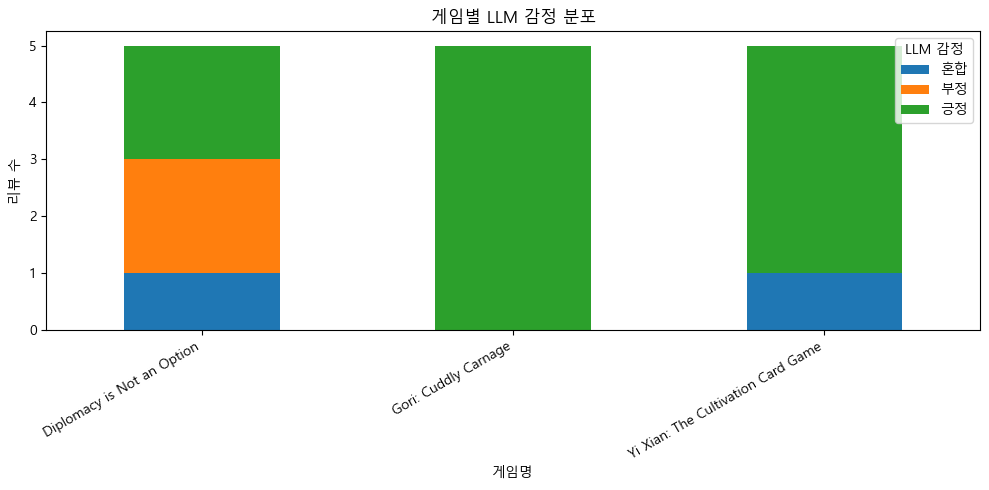

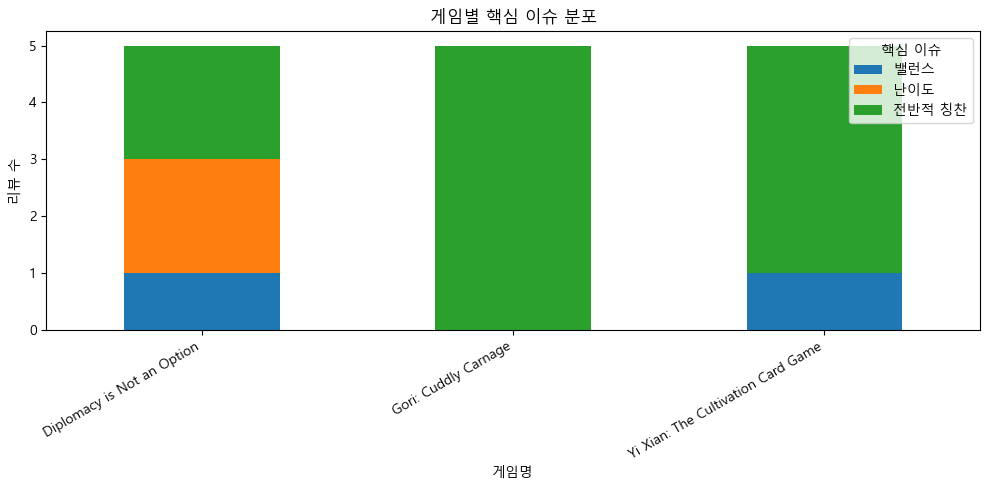

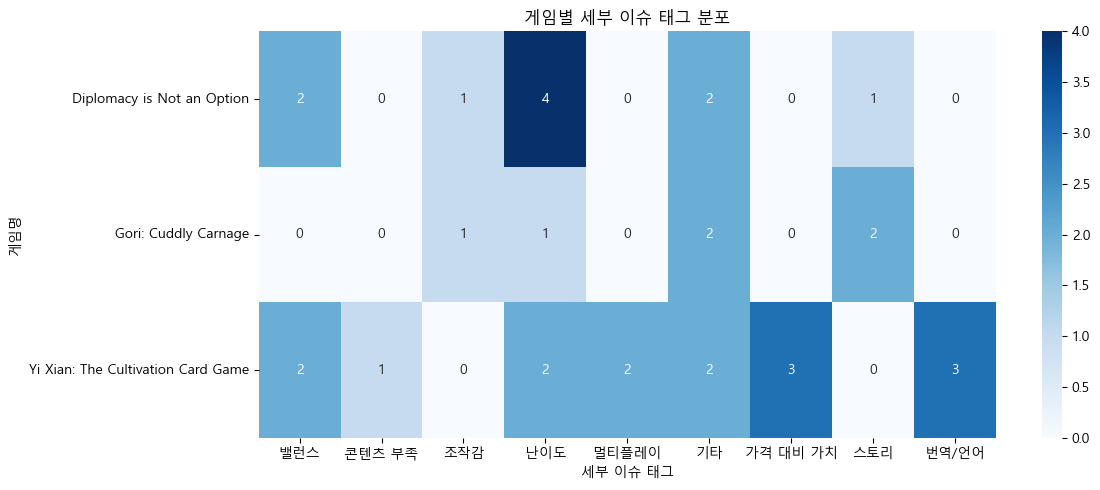

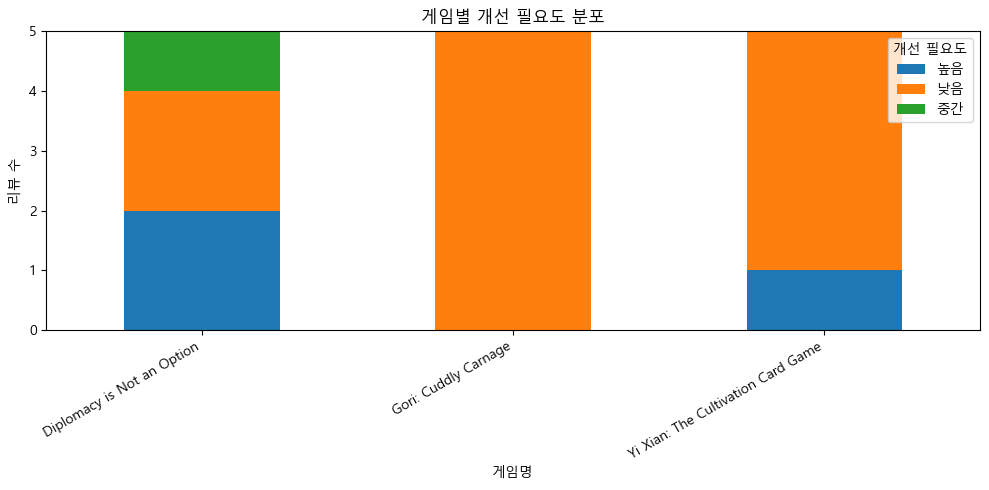

In [59]:
# ============================================================
# 게임 단위 시각화
# - 리뷰별 결과가 아니라 게임별 비교가 가능한 그래프만 출력

# ------------------------------------------------------------
# 1. 게임별 LLM 감정 분포
# ------------------------------------------------------------
sentiment_plot = pd.crosstab(
    df_result["game_name"],
    df_result["llm_sentiment"]
)

sentiment_plot = sentiment_plot.rename(columns=sentiment_kor_map)

sentiment_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("게임별 LLM 감정 분포")
plt.xlabel("게임명")
plt.ylabel("리뷰 수")
plt.xticks(rotation=30, ha="right")
plt.legend(title="LLM 감정")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. 게임별 핵심 이슈 분포
# ------------------------------------------------------------
issue_plot = pd.crosstab(
    df_result["game_name"],
    df_result["primary_issue"]
)

issue_plot = issue_plot.rename(columns=issue_kor_map)

issue_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("게임별 핵심 이슈 분포")
plt.xlabel("게임명")
plt.ylabel("리뷰 수")
plt.xticks(rotation=30, ha="right")
plt.legend(title="핵심 이슈")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. 게임별 세부 이슈 태그 분포
# ------------------------------------------------------------
if len(df_tags) > 0:

    tag_heatmap = pd.crosstab(
        df_tags["game_name"],
        df_tags["tag_category"]
    )

    tag_heatmap = tag_heatmap.rename(columns=issue_kor_map)

    plt.figure(figsize=(12, 5))
    sns.heatmap(
        tag_heatmap,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title("게임별 세부 이슈 태그 분포")
    plt.xlabel("세부 이슈 태그")
    plt.ylabel("게임명")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. 게임별 개선 필요도 분포
# ------------------------------------------------------------
urgency_plot = pd.crosstab(
    df_result["game_name"],
    df_result["urgency"]
)

urgency_plot = urgency_plot.rename(columns=urgency_kor_map)

urgency_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("게임별 개선 필요도 분포")
plt.xlabel("게임명")
plt.ylabel("리뷰 수")
plt.xticks(rotation=30, ha="right")
plt.legend(title="개선 필요도")
plt.tight_layout()
plt.show()
# ============================================================